In [37]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [38]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


In [39]:
TARGET = "EMPLOY"

In [40]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:split+12]

y_true = test_df[TARGET].values

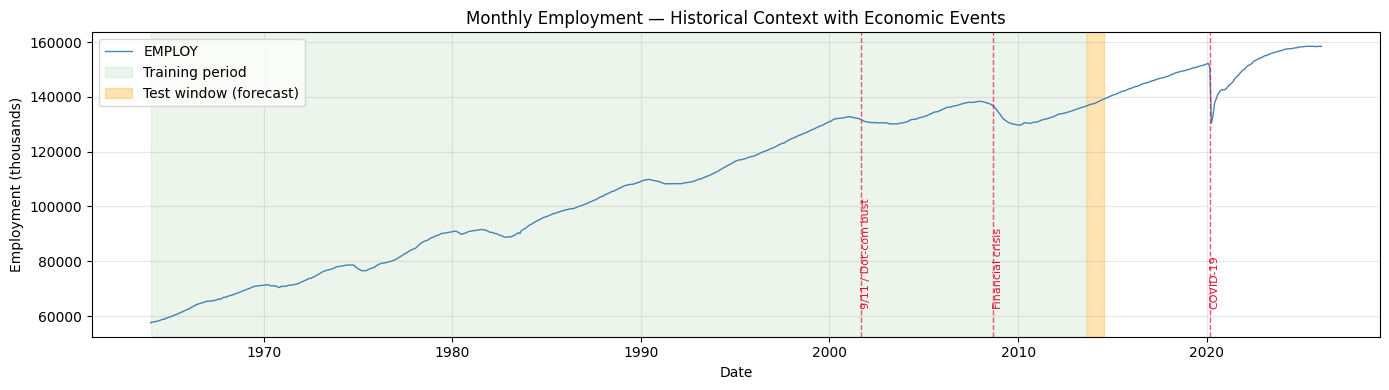

In [41]:
# Historical context: full series with major economic events and train/test boundary
EVENTS = {
    "2001-09-01": "9/11 / Dot-com bust",
    "2008-09-01": "Financial crisis",
    "2020-03-01": "COVID-19",
}

y_max = df[TARGET].max()
y_min = df[TARGET].min()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df["ds"], df[TARGET], color="steelblue", linewidth=1, label=TARGET)

ax.axvspan(train_df["ds"].iloc[0], train_df["ds"].iloc[-1],
           alpha=0.08, color="green", label="Training period")
ax.axvspan(test_df["ds"].iloc[0], test_df["ds"].iloc[-1],
           alpha=0.3, color="orange", label="Test window (forecast)")

for date, label in EVENTS.items():
    ts = pd.Timestamp(date)
    ax.axvline(ts, color="crimson", linestyle="--", linewidth=1, alpha=0.7)
    ax.text(ts, y_min + (y_max - y_min) * 0.05, label,
            rotation=90, fontsize=8, color="crimson", va="bottom")

ax.set_title("Monthly Employment — Historical Context with Economic Events")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [42]:
from chronos import ChronosPipeline
import torch

series = torch.tensor(train_df[TARGET].values, dtype=torch.float32)

pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small")

forecast = pipeline.predict(
    series,
    prediction_length=12,
    num_samples=20
)

chronos_pred = forecast.mean(dim=0)

if len(chronos_pred.shape) > 1:
    chronos_pred = chronos_pred[0]

chronos_pred = chronos_pred.detach().cpu().numpy()

print("Shape:", chronos_pred.shape)
print("Prediction:", chronos_pred)

Shape: (12,)
Prediction: [136522.14 137325.22 137325.22 137325.22 137325.22 137325.22 137325.22
 137325.22 138128.28 138128.28 138128.28 138128.28]


In [43]:
chronos_mae = mean_absolute_error(y_true, chronos_pred)
chronos_mse = mean_squared_error(y_true, chronos_pred)
print(f"Chronos  MAE: {chronos_mae:.2f}")
print(f"Chronos  MSE: {chronos_mse:.2f}")

Chronos  MAE: 506.92
Chronos  MSE: 384870.74


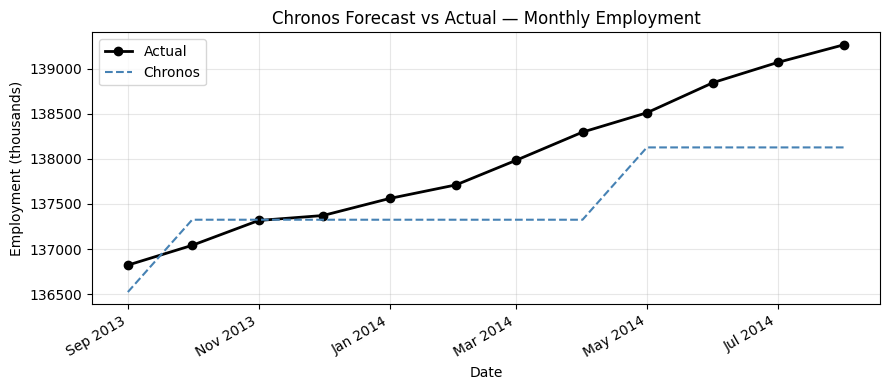

In [44]:
forecast_dates = test_df["ds"].values

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(forecast_dates, y_true, color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, chronos_pred, linestyle="--", color="steelblue", label="Chronos", linewidth=1.5)
ax.set_title("Chronos Forecast vs Actual — Monthly Employment")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [45]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (596, 9)
Test shape: (12, 9)


In [46]:
df_nf = train_df[["ds", TARGET]].copy()

df_nf["unique_id"] = "ts1"
df_nf.rename(columns={TARGET: "y"}, inplace=True)

df_nf.head()

,ds,y,unique_id
300,1964-01-01,57487.0,ts1
301,1964-02-01,57753.0,ts1
302,1964-03-01,57897.0,ts1
303,1964-04-01,57922.0,ts1
304,1964-05-01,58089.0,ts1


In [47]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

model = NBEATS(
    input_size=36,
    h=12,
    max_steps=300
)

nf = NeuralForecast(models=[model], freq="MS")

nf.fit(df_nf)

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.5 M  | train | 0    
---------------------------------------------------------------
2.5 M     Trainable params
1.2 K     Non-trainable params
2.5 M     Total params
9.889     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 27.81it/s, v_num=6, train_loss_step=731.0, train_loss_epoch=731.0]   

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 25.52it/s, v_num=6, train_loss_step=731.0, train_loss_epoch=731.0]


In [48]:
forecast = nf.predict()

nbeats_pred = forecast["NBEATS"].values[-12:]

print("Shape:", nbeats_pred.shape)
print("Prediction:", nbeats_pred)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00,  1.34it/s]
Shape: (12,)
Prediction: [136952.58 137217.12 137367.47 137551.61 137827.9  137965.25 138167.86
 138400.62 138609.38 138740.7  139000.72 139166.52]


In [49]:
nbeats_mae = mean_absolute_error(y_true, nbeats_pred)
nbeats_mse = mean_squared_error(y_true, nbeats_pred)
print(f"N-BEATS  MAE: {nbeats_mae:.2f}")
print(f"N-BEATS  MSE: {nbeats_mse:.2f}")

N-BEATS  MAE: 143.49
N-BEATS  MSE: 24923.65


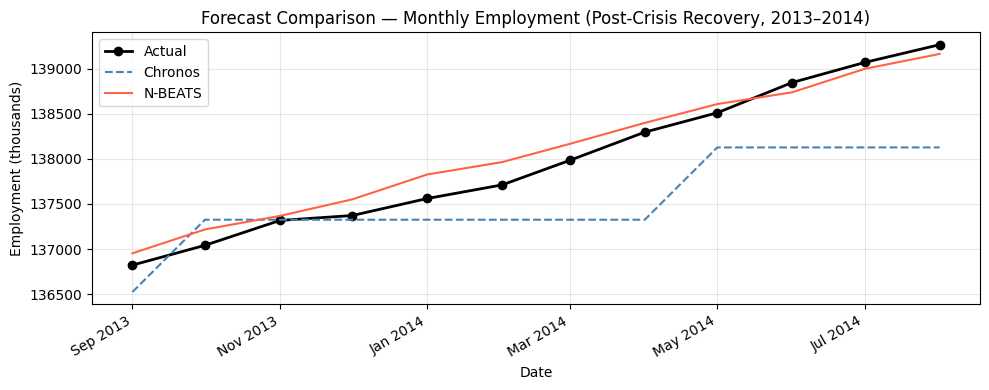


Model               MAE            MSE
--------------------------------------
Chronos          506.92      384870.74
N-BEATS          143.49       24923.65


In [50]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(forecast_dates, y_true, color="black", marker="o", label="Actual", linewidth=2)
ax.plot(forecast_dates, chronos_pred, linestyle="--", color="steelblue", label="Chronos", linewidth=1.5)
ax.plot(forecast_dates, nbeats_pred, color="tomato", label="N-BEATS", linewidth=1.5)
ax.set_title("Forecast Comparison — Monthly Employment (Post-Crisis Recovery, 2013\u20132014)")
ax.set_xlabel("Date")
ax.set_ylabel("Employment (thousands)")
ax.legend()
ax.grid(alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

print(f"\n{'Model':<12} {'MAE':>10} {'MSE':>14}")
print("-" * 38)
print(f"{'Chronos':<12} {chronos_mae:>10.2f} {chronos_mse:>14.2f}")
print(f"{'N-BEATS':<12} {nbeats_mae:>10.2f} {nbeats_mse:>14.2f}")